Program 01 - Regression to Predict MEDV - Boston Housing

In [1]:
import pandas as pd
import matplotlib.pyplot as plt


Step 1 :Read Data from the dataset housing after uploading it to runtime folder

In [4]:
# Read in data from housing.csv
data = pd.read_csv('/housing.csv')
print(data.head())

      RM  LSTAT  PTRATIO      MEDV
0  6.575   4.98     15.3  504000.0
1  6.421   9.14     17.8  453600.0
2  7.185   4.03     17.8  728700.0
3  6.998   2.94     18.7  701400.0
4  7.147   5.33     18.7  760200.0


This dataset has 4 columns. We're using 3 as features:

RM : Average number of rooms per dwelling in the area measured. LSTAT: Percentage of population in the measured area that are lower income/lower socio-economoic status PTRATIO: Pupil-teacher ratio in the measured area. The 4th we're using as our target variable:

MEDV: Median value of homes in the measured area Let's use some scatter plots to visualize the relationship of each of the features with our target variable, MEDV

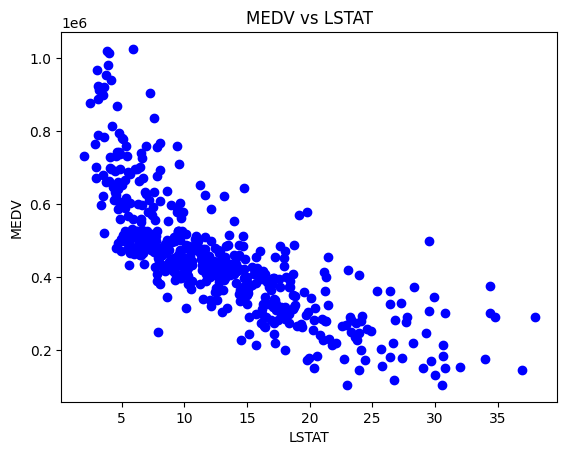

In [5]:
# Visualize the relation of MEDV and LSTAT using a scatter plot
plt.scatter(data['LSTAT'], data['MEDV'], color='blue')
plt.title('MEDV vs LSTAT')
plt.xlabel('LSTAT')
plt.ylabel('MEDV')
plt.show()

Nice, we can see that this has a roughly linear relationship with a negative coorelation - as percentage of lower-income population increases, median home value decreases, which makes sense

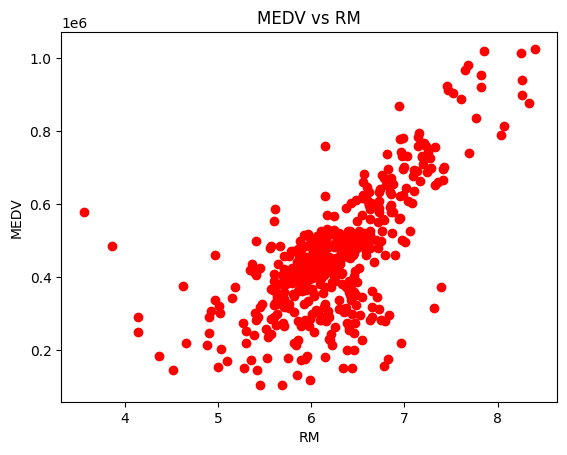

In [6]:
# Visualize the relation of MEDV and RM using a scatter plot
plt.scatter(data['RM'], data['MEDV'], color='red')
plt.title('MEDV vs RM')
plt.xlabel('RM')
plt.ylabel('MEDV')
plt.show()

Again, a roughly linear relationship, this time with a positive coorelation. As the average number of rooms per dwelling increases, so does median value. Again, this makes sense.

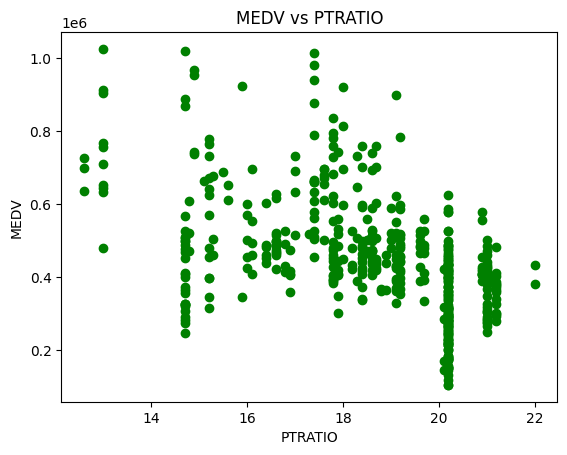

In [7]:
# Visualize the relation of MEDV and PTRATIO using a scatter plot
plt.scatter(data['PTRATIO'], data['MEDV'], color='green')
plt.title('MEDV vs PTRATIO')
plt.xlabel('PTRATIO')
plt.ylabel('MEDV')
plt.show()

This one is a bit more mixed. The correlation isn't so clear between pupil-teacher ratio and median home value. The data looks all over the place. Let's try a Linear Regression just using our basic features.

In [8]:
# Split the data into features and target
X = data[['LSTAT', 'RM', 'PTRATIO']]
y = data['MEDV']

# Split the data into training and test sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=0)

# Train a linear regression model
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

# Evaluate the model
y_pred = model.predict(X_test)

from sklearn.metrics import mean_squared_error
mse = mean_squared_error(y_test, y_pred)
# Convert the mean squared error to a more readable dollar value
import math
mse = math.sqrt(mse)
print(f'Mean Error: ${mse}')

Mean Error: $94420.53496266241


In [9]:
# Drop the PTRATIO feature and retrain the model
X = data[['LSTAT', 'RM']]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=0)

model = LinearRegression()
model.fit(X_train, y_train)

# Evaluate the model
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
mse = math.sqrt(mse)
print(f'Mean Error without PTRATIO: ${mse}')

Mean Error without PTRATIO: $99583.46044725577
